In [1]:
import os
os.getcwd()

'C:\\OIBSIP\\CustomerSegmentation'

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [9]:
df = pd.read_csv("retail_sales_dataset.csv")

In [5]:
import pandas as pd
print(pd.__version__)

3.0.5


In [7]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("retail_sales_dataset.csv")

In [12]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [14]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [20]:
latest_date = df['Date'].max()

latest_date

Timestamp('2024-01-01 00:00:00')

In [21]:
df['Date'] = pd.to_datetime(df['Date'])

In [22]:
latest_date = df['Date'].max()
latest_date

Timestamp('2024-01-01 00:00:00')

In [25]:
rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (latest_date - x.max()).days,
    'Transaction ID': 'count',
    'Total Amount': 'sum'
})

In [24]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [26]:
rfm.head()

,Date,Transaction ID,Total Amount
Customer ID,,,
CUST001,38,1,150
CUST002,308,1,1000
CUST003,353,1,30
CUST004,225,1,500
CUST005,240,1,100


In [27]:
rfm['Avg Purchase Amount'] = rfm['Monetary'] / rfm['Frequency']

KeyError: 'Monetary'

In [28]:
rfm.columns

Index(['Date', 'Transaction ID', 'Total Amount'], dtype='str')

In [29]:
rfm = df.groupby('Customer ID').agg(
    Recency=('Date', lambda x: (latest_date - x.max()).days),
    Frequency=('Transaction ID', 'count'),
    Monetary=('Total Amount', 'sum')
)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
CUST001,38,1,150
CUST002,308,1,1000
CUST003,353,1,30
CUST004,225,1,500
CUST005,240,1,100


In [30]:
rfm['Avg Purchase Amount'] = rfm['Monetary'] / rfm['Frequency']

In [31]:
rfm.head()

,Recency,Frequency,Monetary,Avg Purchase Amount
Customer ID,,,,
CUST001,38,1,150,150.0
CUST002,308,1,1000,1000.0
CUST003,353,1,30,30.0
CUST004,225,1,500,500.0
CUST005,240,1,100,100.0


In [32]:
rfm['Monetary']

Customer ID
CUST001     150
CUST002    1000
CUST003      30
CUST004     500
CUST005     100
           ... 
CUST995      30
CUST996      50
CUST997      90
CUST998     100
CUST999     150
Name: Monetary, Length: 1000, dtype: int64

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

In [35]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [36]:
rfm_scaled[:5]

array([[-1.36833645,  0.        , -0.5467043 ],
       [ 1.19761513,  0.        ,  0.97191876],
       [ 1.62527373,  0.        , -0.76109815],
       [ 0.40882261,  0.        ,  0.07861108],
       [ 0.55137548,  0.        , -0.63603507]])

In [37]:
rfm_scaled[:5]

array([[-1.36833645,  0.        , -0.5467043 ],
       [ 1.19761513,  0.        ,  0.97191876],
       [ 1.62527373,  0.        , -0.76109815],
       [ 0.40882261,  0.        ,  0.07861108],
       [ 0.55137548,  0.        , -0.63603507]])

In [38]:
from sklearn.cluster import KMeans

In [39]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

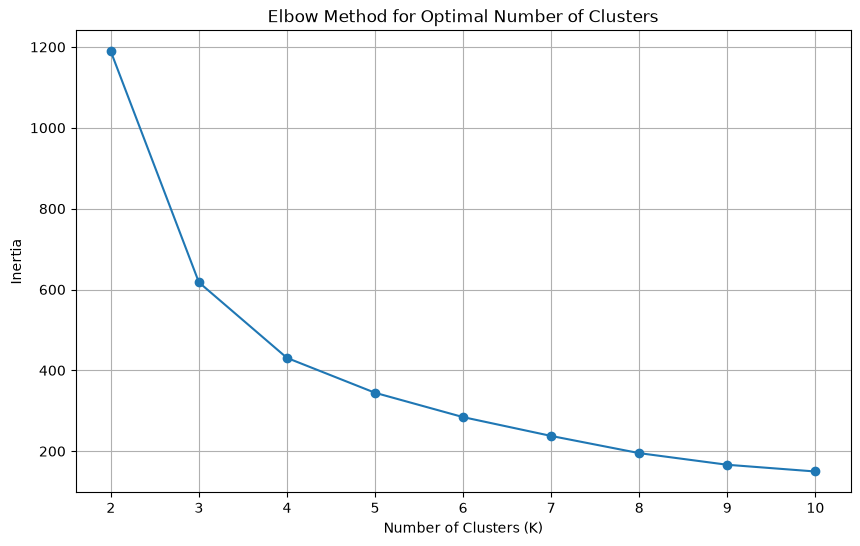

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [41]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

In [42]:
from sklearn.cluster import KMeans

In [43]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

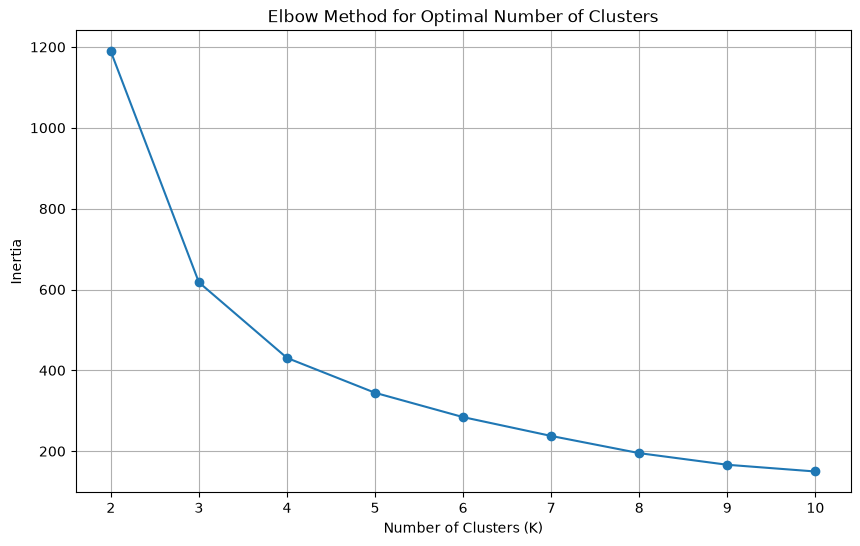

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [45]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [46]:
rfm.head()

,Recency,Frequency,Monetary,Avg Purchase Amount,Cluster
Customer ID,,,,,
CUST001,38,1,150,150.0,1
CUST002,308,1,1000,1000.0,0
CUST003,353,1,30,30.0,2
CUST004,225,1,500,500.0,2
CUST005,240,1,100,100.0,2


In [47]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

cluster_counts

Cluster
0    140
1    370
2    366
3    124
Name: count, dtype: int64

In [48]:
rfm.head()

,Recency,Frequency,Monetary,Avg Purchase Amount,Cluster
Customer ID,,,,,
CUST001,38,1,150,150.0,1
CUST002,308,1,1000,1000.0,0
CUST003,353,1,30,30.0,2
CUST004,225,1,500,500.0,2
CUST005,240,1,100,100.0,2


In [49]:
cluster_counts

Cluster
0    140
1    370
2    366
3    124
Name: count, dtype: int64

In [50]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Avg Purchase Amount': 'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary,Avg Purchase Amount
Cluster,,,,
0,269.52,1.0,1283.57,1283.57
1,91.12,1.0,159.77,159.77
2,273.57,1.0,148.32,148.32
3,83.94,1.0,1313.71,1313.71


In [51]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()
cluster_counts

Cluster
0    140
1    370
2    366
3    124
Name: count, dtype: int64

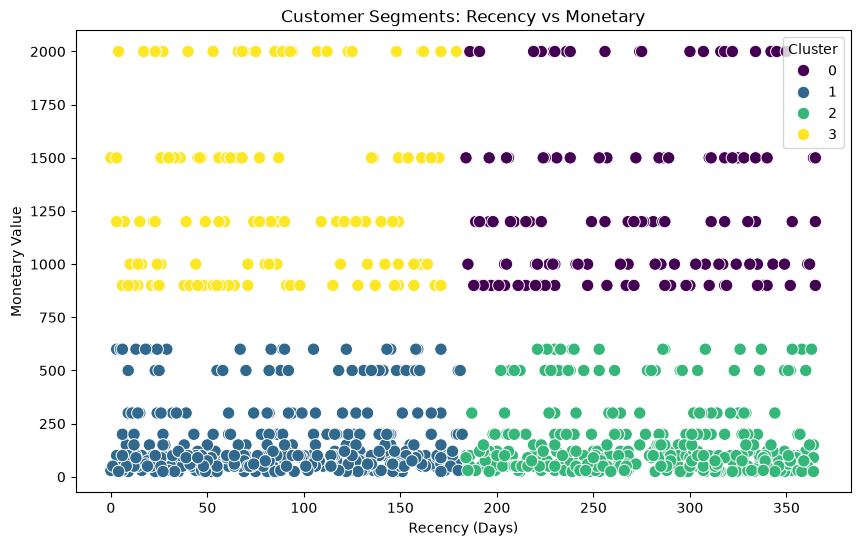

In [52]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')

plt.show()

In [53]:
cluster_names = {
    0: 'High-Value Inactive',
    1: 'Recent Low-Value',
    2: 'Low-Value Inactive',
    3: 'Recent High-Value'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Avg Purchase Amount,Cluster,Segment
Customer ID,,,,,,
CUST001,38,1,150,150.0,1,Recent Low-Value
CUST002,308,1,1000,1000.0,0,High-Value Inactive
CUST003,353,1,30,30.0,2,Low-Value Inactive
CUST004,225,1,500,500.0,2,Low-Value Inactive
CUST005,240,1,100,100.0,2,Low-Value Inactive


In [55]:
rfm['Segment'].value_counts()

Segment
Recent Low-Value       370
Low-Value Inactive     366
High-Value Inactive    140
Recent High-Value      124
Name: count, dtype: int64

## Customer Segment Marketing Strategies

### 1. High-Value Inactive Customers
These customers have high monetary value but have not purchased recently.
The business should use personalized re-engagement campaigns, exclusive
discounts, and product recommendations to encourage another purchase.

### 2. Recent Low-Value Customers
These customers purchased recently but have relatively low spending.
The business can use cross-selling, product bundles, and personalized
recommendations to increase their average order value.

### 3. Low-Value Inactive Customers
These customers have low spending and have not purchased recently.
The business should use low-cost promotional campaigns and targeted
offers to determine whether these customers can be reactivated.

### 4. Recent High-Value Customers
These are the most valuable current customers because they purchased recently
and have high monetary value. The business should prioritize retention,
personalized offers, loyalty incentives, and premium product recommendations.

In [56]:
segment_summary = rfm.groupby('Segment').agg(
    Customers=('Segment', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Purchase=('Avg Purchase Amount', 'mean')
).round(2)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Purchase
Segment,,,,,
High-Value Inactive,140,269.52,1.0,1283.57,1283.57
Low-Value Inactive,366,273.57,1.0,148.32,148.32
Recent High-Value,124,83.94,1.0,1313.71,1313.71
Recent Low-Value,370,91.12,1.0,159.77,159.77


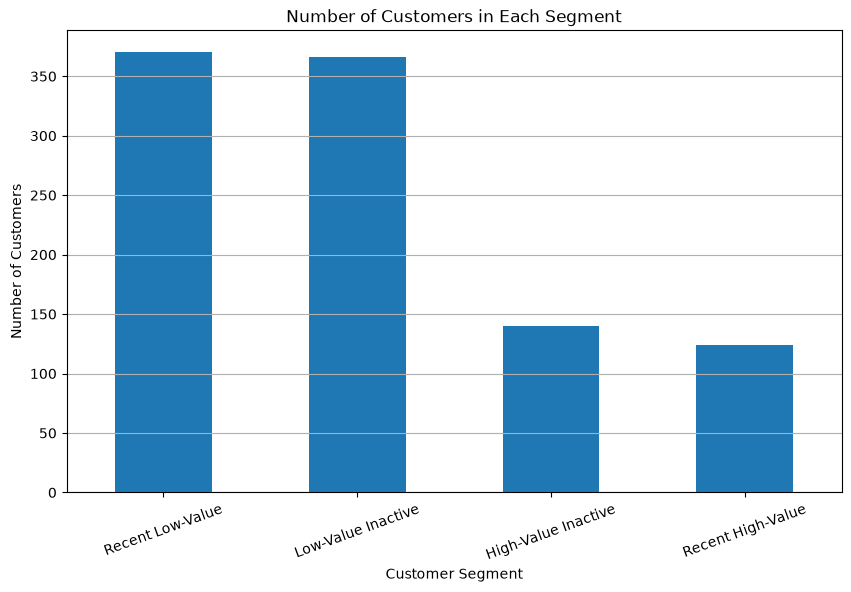

In [57]:
plt.figure(figsize=(10, 6))

rfm['Segment'].value_counts().plot(kind='bar')

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.grid(axis='y')

plt.show()

## Conclusion

Customer segmentation was performed using an RFM-style approach based on
Recency, Frequency, and Monetary value.

The Elbow Method was used to select four customer clusters, followed by
K-Means clustering. The resulting segments were analyzed based on their
recency and monetary characteristics.

The analysis identified recent high-value customers, recent low-value
customers, high-value inactive customers, and low-value inactive customers.

The segmentation can help the business develop targeted marketing strategies
for different customer groups.

### Dataset Limitation

Each customer in this dataset has only one recorded transaction. Therefore,
Frequency is equal to 1 for all customers, limiting the ability to identify
repeat-purchase behavior or true customer loyalty. The segmentation is
therefore primarily based on Recency and Monetary value.